<div style="
    background: linear-gradient(90deg, #e8f4f3, #dff0ee);
    border: 2px solid #2c7f7b;
    padding: 20px;
    border-radius: 8px;
    font-size: 22px;
    text-align: center;
    margin-top: 30px;
    margin-bottom: 30px;
">
<strong>⚙️ Stage 1 — Setup and Run</strong><br><br>
Configure and launch the Carbonara pipeline.  

Prepare inputs, define the search, start the run, and initialise monitoring of backmapping and FOXS evaluation.
</div>

<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>🧠 Configure search:</strong><br><br>
This cell sets up the main Carbonara search algorithm.  

Provide a project name (<code>run_name</code>), along with the input structure (<code>pdb_name</code>) and SAXS data file (<code>saxs_name</code>).  
Optionally, include a PAE file (<code>pae_name</code>) to guide flexibility. 

In this version we set up the run to try mixture fittings (e.g can I fit with the structure in two different states in say a 40%/60% ratio?). One selects the number of states to try with mixture_n then the number of combinations to try i.e. 10-90,20-80 e.t.c. For a large mixture_n a Latin hypercube sampler is used to slect the combinations, we reccome 5 per state (2->10, 3->15 e.t.c).


The setup will then be initialised. See the README for the full range of configuration options.
</div>

In [15]:
import sys
import modeller
from modeller import environ

print(sys.executable)
print(modeller.__file__)

env = environ()
print("MODELLER OK")

/extra/tmp/carbonara-refold/.venv/bin/python
/usr/lib64/python3.14/site-packages/modeller/__init__.py

                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, O

In [19]:
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.mmcifio import MMCIFIO

# Load the .cif file
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("original", "pdbFiles/4F5S.cif")

# Extract the first chain from the first model
model = structure[0]
first_chain = list(model.get_chains())[0]

# Save as a new .cif file
io = MMCIFIO()
io.set_structure(first_chain)
io.save("pdbFiles/4F5S.chain1.cif")

In [22]:
import CarbonaraDataTools as CDT
import numpy as np
import re
import fittingAnalysis as fa
import pickle

# @title Run this to set the carbonara model up with a given run name
run_name = "BSA_MULT"
pdb_name = "pdbFiles/4F5S.chain1.cif"
saxs_name = "saxsFiles/SASDA32.dat"

# if we have a pae  unhash this and give its location
#pae_name ="<pae_location>"

# choose the number of structures to fit simletaneously
mixture_no = 3

# choose the number of mixture combinations  to try
no_combinations = 20

import sys
!{sys.executable} setup_carbonara_allAtom.py -p $pdb_name -s $saxs_name -n $run_name --rotation --mixture_n $mixture_no --max_mixture_combos $no_combinations 

# for use with pae file (f for flexibility)

#!{sys.executable} setup_carbonara_allAtom.py -p $pdb_name -s $saxs_name -f $pae_name -n $run_name --alphaFoldFlex --rotation --mixture_n mixture_no --max_mixture_combos no_combinations 


import sys
from pathlib import Path

foxs_script = Path("external/pyFoXS/pyFoXS/foxs.py").resolve()
foxs_cmd = f'"{sys.executable}" "{foxs_script}"'

DIR: /extra/tmp/carbonara-refold
/extra/tmp/carbonara-refold
new
Created directory structure in: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT
The number of chains is  1
100%|██████████████████████████████████████████| 32/32 [00:07<00:00,  4.55it/s]

Setup completed successfully!
Initial files were created in: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT
Files for Carbonara were copied to: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT
Run script created at: /extra/tmp/carbonara-refold/RunMe_BSA_MULT.sh
Watcher/backmapping Python: /extra/tmp/carbonara-refold/.venv/bin/python
Run mode: maximal exploration (no individual predictor processes are terminated early)

To run the refinement, execute:
cd /extra/tmp/carbonara-refold && ./RunMe_BSA_MULT.sh


<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📈 Initial scattering check:</strong><br><br>
This cell runs an initial FoXS check using the starting structure and experimental SAXS data.  
It reports the initial <code>&chi;<sup>2</sup></code> value and shows the corresponding fit and residuals.<br><br>

This gives a quick indication of how well the starting model already agrees with the data.  
In general, a poorer initial fit may mean that Carbonara will need longer to find good-fitting conformations.  
The plot also helps identify where the main discrepancies lie across the scattering curve.<br><br>

You may optionally set a maximum fitting range <code>max_q</code>.  
This can be useful if you want to focus on larger-scale structural features carried by the low-<code>q</code> region.  
For example, the initial fit may improve substantially as the fitted range is restricted, which can indicate that the main mismatch lies at higher <code>q</code>.  
Although Carbonara typically uses <code>q = 0.2</code> as its default upper limit, you may prefer a smaller value such as <code>q = 0.1</code> if your main interest is in low-<code>q</code> behaviour.

['/extra/tmp/carbonara-refold/.venv/bin/python', '/extra/tmp/carbonara-refold/external/pyFoXS/pyFoXS/foxs.py', '/tmp/tmpgda_1hq4.pdb', '/extra/tmp/carbonara-refold/saxsFiles/SASDA32.dat', '--max_q', '0.2']
Initial FoXS chi^2: 13.7


/extra/tmp/carbonara-refold/CarbonaraDataTools.py:3052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


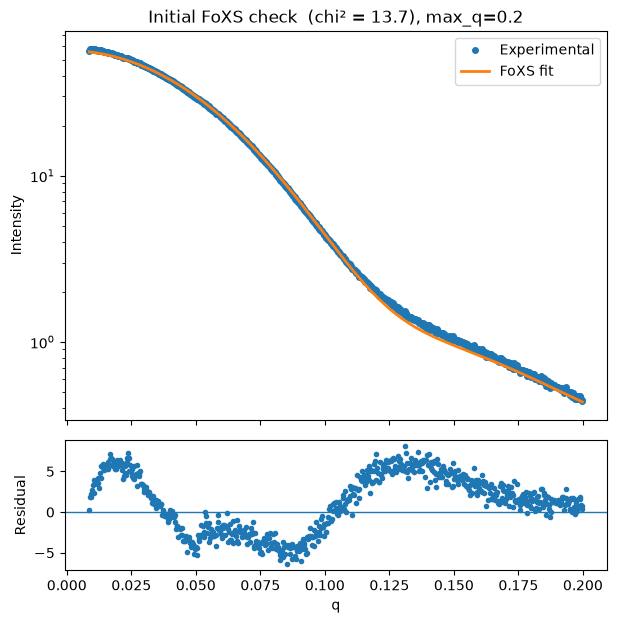

In [23]:
max_q=0.2

foxs_result = CDT.run_initial_foxs_check(
    pdb_name=pdb_name,
    saxs_name=saxs_name,
    foxs_cmd=foxs_cmd,
     max_q =max_q
)

In [ ]:
# if you want to fit on max_q <0.2 (say max_q =0.1) you set it here

CDT.toggle_startk("carbonara/RunMe_"+run_name+".sh",max_q)

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>🔗 Multimer merging (advanced, optional):</strong><br><br>
Use this section to merge selected chains so that they move together as a single unit during fitting.  

This is intended for multimeric systems where some chains form rigid subunits, and only the relative motion between those subunits should be sampled.  

Work through the steps carefully. After each merge, check that the highlighted flexible segments still correspond to the intended regions before applying the changes permanently.
</div>

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 1 — Inspect the current chain layout</strong><br><br>
Run this cell to display the current chain and segment organisation.  
Segments highlighted in red are those currently selected for variation.
</div>

In [ ]:
# First lets look at the chains
filename = "carbonara_runs/"+run_name+"/fingerPrint1.dat"
highlight_segments = np.loadtxt("carbonara_runs/"+run_name+"/varyingSectionSecondary1.dat",dtype=int)

chains = CDT.parse_structures_with_segments(filename)
CDT.print_structure_with_highlights(chains,highlight_segments)

#The segments highlighted in red below are those selected for changing

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 2 — Preview a proposed chain merge</strong><br><br>
Choose the pair of chains to merge, then run this cell to preview the updated chain structure and flexible segments.  

Check carefully that the red highlighted regions still match the intended flexible parts of the model.
</div>

In [ ]:
#Say we want to merge chains 1 and 2

# Load data
chains = CDT.parse_structures_with_segments("carbonara_runs/"+run_name+"/fingerPrint1.dat")
original_segments = np.loadtxt("carbonara_runs/"+run_name+"/varyingSectionSecondary1.dat",dtype=int)

#choose the merge pair
merge_pair = (1,2)

#calculate the new varying sections

original_labels, editable_labels, filtered_segments = CDT.create_segment_label_arrays_with_merge_v4(
    chains,
    highlighted_segments=original_segments,
    merge_pair=merge_pair
)

#update the seqences

merged_chains =CDT.merge_chains_only_clean_consistent_segments(chains, merge_pair)


#check (look to see if the red highlighted sections are where they should be)

CDT.print_structure_with_highlights(merged_chains,filtered_segments)

<div style="
    background-color: #fff3cd;
    border-left: 6px solid #d39e00;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 3 — Apply the merge</strong><br><br>
Run this cell only if you are happy with the preview.  
It overwrites the model files so that the merged chain layout and updated flexible segments are used in subsequent fitting.
</div>

In [ ]:

# update the sequence data in the model's filesystem so this merged state is used in the fitting
CDT.export_chains_to_file(merged_chains,"carbonara_runs/"+run_name+"/fingerPrint1.dat")

#Up date the labelling of the varying sections.
CDT.export_segment_list(filtered_segments,"carbonara_runs/"+run_name+"/varyingSectionSecondary1.dat")

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 4 — Repeat if further merges are needed</strong><br><br>
If additional chain merges are required, repeat the process using the updated chain numbering.  

Be careful: after each merge, the chain indices change. For example, after merging chains 1 and 2, the original chains 3 and 4 may become chains 2 and 3.
</div>

<div style="
    background-color: #fdecea;
    border-left: 6px solid #d9534f;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>⚠️ Important:</strong><br><br>
After a merge is applied, chain numbering is updated. Always re-check the current chain indices before performing the next merge.
</div>

In [ ]:
# In the example I am thinking of segments 3 and 4 also need to be merged so we can do it again BUT BE CAREFUL, this will now be chains 2 and 3

merge_pair = (2,3)

# Load data
chains = CDT.parse_structures_with_segments("carbonara_runs/"+run_name+"/fingerPrint1.dat")
original_segments = np.loadtxt("carbonara_runs/"+run_name+"/varyingSectionSecondary1.dat",dtype=int)

# Merge chains 2 and 3
original_labels, editable_labels, filtered_segments = CDT.create_segment_label_arrays_with_merge_v4(
    chains,
    highlighted_segments=original_segments,
    merge_pair=merge_pair
)

#update the seqences

merged_chains =CDT.merge_chains_only_clean_consistent_segments(chains, merge_pair)

#check (look to see if the red highlighted sections are where they should be)

CDT.print_structure_with_highlights(merged_chains,filtered_segments)

<div style="
    background-color: #fff3cd;
    border-left: 6px solid #d39e00;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 3 — Apply the merge</strong><br><br>
Run this cell only if you are happy with the preview.  
It overwrites the model files so that the merged chain layout and updated flexible segments are used in subsequent fitting.
</div>

In [ ]:
# @title Again, IF you are happy set these changes in place
# update the sequence data in the model's filesystem so this merged state is used in the fitting
CDT.export_chains_to_file(merged_chains,"carbonara_runs/"+run_name+"/fingerPrint1.dat")

#Up date the labelling of the varying sections.
CDT.export_segment_list(filtered_segments,"carbonara_runs/"+run_name+"/varyingSectionSecondary1.dat")

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📏 Distance constraints (advanced, optional):</strong><br><br>
Use this section to add distance constraints to the model, for example from contact predictions, disulfide bonds, or FRET measurements.  

Two input methods are supported:
<ul style="margin-top:6px;">
<li>load constraints from a file,</li>
<li>define them directly as an array.</li>
</ul>

The file-based method is recommended for most users.  
The array method is the quickest, but should only be used if you are confident with the required format.
</div>

<div style="
    background-color: #fff3cd;
    border-left: 6px solid #d39e00;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📏 Method 1: Load constraints from file (applies changes):</strong><br><br>
Use this option to import a list of fixed distance constraints from a file.  

Each line should have the format:<br>
<code>residue1 chain1 residue2 chain2 distance</code><br><br>

For example:<br>
<code>125 A 234 C 15</code><br><br>

Running this cell updates the model files so these constraints are enforced during fitting.
</div>

In [ ]:
fd_file = "<distance constraint file>"

# Chain lengths (automatically known)

with open('carbonara_runs/'+run_name+"/chainLengths.dat",'rb') as f:
   chain_lengths = pickle.load(f)

# convert the predictions to the Carbonara model forat
contactPreds,fixedDists = CDT.mapFixedConstraints(fd_file, chain_lengths)

# Set in place in the fit files
CDT.translate_distance_constraints(contactPreds, np.genfromtxt("carbonara_runs/"+run_name+ '/coordinates1.dat'),"carbonara_runs/"+run_name, fixedDists)

# Turn on the distance constraint functionality
CDT.toggle_paired_predictions("RunMe_"+run_name+".sh")

<div style="
    background-color: #fff3cd;
    border-left: 6px solid #d39e00;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Method 2 — Define constraints as an array</strong><br><br>
This is the quickest method, but it assumes you already know the required array structure and indexing conventions.  
Use it only if you are comfortable editing constraint data directly.
</div>

In [ ]:
#Example 1 set pairs to aim for 6 A

#contactPreds = [[136,680],[149,205],[225,591],[231,686],[264,329],[375,435],[477,551],[604,660],[719,784],[830,890]]
#fixedDistSet = [6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0]

#Example 2 Set pairs to preserve their initial distances.

contactPreds = [[136,680],[149,205],[225,591],[231,686],[264,329],[375,435],[477,551],[604,660],[719,784],[830,890]]
fixedDistSet = []

# Set in place in the fit files
CDT.translate_distance_constraints(contactPreds, np.genfromtxt("carbonara_runs/"+run_name+ '/coordinates1.dat'),"carbonara_runs/"+run_name, fixedDistSet)

# Turn on the distance constraint functionality
CDT.toggle_paired_predictions("RunMe_"+run_name+".sh")

<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>⚙️ Initialise run:</strong><br><br>
This cell starts the Carbonara pipeline and initialises the live monitoring system.  
As the search progresses, the monitor performs all-atom backmapping and FoXS evaluation on generated structures.<br><br>

Choose a <code>&chi;<sup>2</sup></code> threshold to define what constitutes a <em>high-quality</em> fit (for example, <code>threshold = 2.5</code> selects structures with <code>&chi;<sup>2</sup> &lt; 2.5</code>).<br><br>

The parameter <code>defer_backmap_seconds</code> controls how long the algorithm waits before beginning all-atom reconstruction.  
If the initial structure is a poor fit, early iterations often produce many intermediate improvements that are not yet high quality.  
Delaying backmapping (e.g. 600 seconds) reduces backlog and focuses computation on more promising structures.<br><br>

The parameter <code>every_s</code> sets how frequently the monitor updates (in seconds), controlling how often new results are checked and processed.
</div>

In [24]:
from pathlib import Path
from run_frontend import CarbonaraRunner

runner = CarbonaraRunner(run_name, foxs_cmd=foxs_cmd)
runner.start()
runner.start_monitor(threshold=2.5, every_s=10, defer_backmap_seconds=600)

✅ Biopython/Bio.PDB check passed
ℹ️ No backmapping method detected in run script; skipping MODELLER preflight check
🚀 Carbonara started (PID=767389)
🐍 Watcher/backmapping Python: /extra/tmp/carbonara-refold/.venv/bin/python


## 🔬 Carbonara Live Monitor

**Backmapping starts in:** 479 s
**Status:** Waiting period active. Early predictions are being ignored.
**Monitor threshold (χ²):** 2.5
**Mixture components:** 3
**Run mode:** maximal exploration
**Good models:** 0 / 0
**Errors:** 0
**Last sweep:** 15:57:55

📊 Monitoring started (mixture_n=3, mode=maximal exploration)


<div style="
    background-color: #fdecea;
    border-left: 6px solid #d9534f;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>🛑 Terminate run:</strong><br><br>
Run this cell to stop Carbonara.  

It will be terminated.
</div>

In [ ]:
runner.stop()
runner.stop_monitor()

<div style="
    background: linear-gradient(90deg, #f4f1fb, #e9e4f7);
    border: 2px solid #7a5cc;
    padding: 20px;
    border-radius: 8px;
    font-size: 22px;
    text-align: center;
    margin-top: 30px;
    margin-bottom: 30px;
">
<strong>📊 STAGE 2 — ANALYSIS</strong><br><br>
Analyse the generated predictions, quantify structural variation, and interpret ensemble behaviour.<br><br>

<div style="
    background-color: #ffffff;
    border-left: 5px solid #7a5cc;
    padding: 10px;
    font-size: 16px;
    border-radius: 5px;
">
<strong>⏱️ You can start this immediately.</strong><br>
There is no need to wait for the Carbonara run to finish — analysis can be performed while the algorithm is still running.
</div>
</div>

In [ ]:
import backmapping_funcs as bm
import CarbonaraDataTools as cdt
import fittingAnalysis as fa
import numpy as np
import os
import json
import pickle
import sys
sys.path.insert(0, "./_local_pkgs")

directory = "carbonara_runs/"+run_name
run = "fitdata"

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📥 Collect predictions:</strong><br><br>
At this stage you can gather predictions in one of two ways.<br><br>

Use the <em>all predictions</em> option to collect every structure that passes the chosen <code>&chi;<sup>2</sup></code> threshold.  
This is useful for more detailed or advanced analysis, but may include many closely related structures, especially from the same run.<br><br>

Use the <em>best per run</em> option to collect just one representative structure from each run, chosen as the prediction whose <code>&chi;<sup>2</sup></code> is closest to 1.  
This gives a smaller, more manageable set and often provides a clearer overview of the distinct outcomes across runs.
</div>

In [ ]:
# a) Use all predictions option, just run

directory = "carbonara_runs/"+run_name
run = "fitdata"

good_preds = fa.collect_good_prediction_files(
    fitdata_dir=directory+"/"+run,
    chi2_threshold=2.5
)

print(f"Found {len(good_preds)} good predictions")
#for pdb, chi2 in good_preds[:len(good_preds)]:
 #   print(f"{chi2:.3f}  {pdb}")
highQualityPredictions= [pdb for pdb, chi2 in good_preds]

In [27]:
# b) Best per run option, just run

directory = "carbonara_runs/"+run_name
run = "fitdata"

best_preds = fa.collect_best_prediction_per_run_closest_to_one(
    fitdata_dir=directory + "/" + run
)

for run_no, entry in enumerate(best_preds, start=1):
    if entry is None:
        print(f"Run {run_no}: no valid prediction yet")
    else:
        _, chi2 = entry
        print(f"Run {run_no}: chi² = {chi2:.3f}")

highQualityPredictions = [
    entry[0] if entry is not None else None
    for entry in best_preds
]

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📏 Compare structural variation:</strong><br><br>
Run these cells to quantify structural variation using RMSD or TM-score.  

This compares:
<ul style="margin-top:6px;">
<li>variation between predictions (ensemble diversity),</li>
<li>deviation from the original structure (extent of structural change).</li>
</ul>
</div>

In [ ]:
# Run to calculate the variation between predictions

validPreds = [p for p in highQualityPredictions if p is not None]

rmsdPairedComparisons = fa.pairwise_structure_metrics(
    validPreds,
    fa.compare_structures_vals
)

In [ ]:
# Run to calculate the variation between predictions and the original structure

originalPdb = "pdbFiles/5_C239S.pdb"

validPreds = [p for p in highQualityPredictions if p is not None]

rmsdToOriginal = fa.structure_metrics_vs_carbonara(
    pdb_files=validPreds,
    carbonara_dir=directory,
    compare_func=fa.compare_structures_vals_carbonara
)

In [ ]:
# Run to view histograms of these values

metric = "rmsd"
#could be 'tm' or 'gdt_ts'


fa.plot_overlaid_histograms([rmsdPairedComparisons,rmsdToOriginal],
    "rmsd",
    ["Carbonara-Carbonara","Carbonara-Original"],
    "RMSD (Angstroms)",
    "Comparative variations in RMSD Score of IL predictions",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📐 Analyse radius of gyration (Rg):</strong><br><br>
Run this cell to examine the distribution of Rg across predictions.  

This includes both individual structures and mixtures of predictions (ensembles), allowing you to assess overall compactness and structural spread.
</div>

In [ ]:
# you can look in the variation in Radius of Gyration also
validPreds = [p for p in highQualityPredictions if p is not None]

rg_results = fa.calc_rg_distribution(
    pdb_files=validPreds,
    rg_func=fa.radius_of_gyration,
    weighted=False
)

# Rg of the original PDB
originalPdb = "pdbFiles/5_C239S.pdb"

rg_results_og = fa.calc_rg_distribution(
    pdb_files=[originalPdb],
    rg_func=fa.radius_of_gyration,
    weighted=False
)

In [ ]:
# to view the Rg histograms

metric = "rg"

fa.plot_overlaid_histograms([rg_results,rg_results_og],
    metric,
    ["carbonra predictions","original model"],
    "Rg (Angstroms)",
    "Variation in Rg of carbonara predictions compared to homology model",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>🧬 Visualise structures (3D):</strong><br><br>
Run this cell to explore predictions using 3D cartoon representations (requires that pymol3d installed)

You can view individual structures, compare predictions, and overlay them with the original structure to assess structural differences.
</div>

In [ ]:
#View a prediction, check it exists first ! 


fa.visualisePredictionIndividual(highQualityPredictions[2])

In [ ]:
# compare the prediction to the original (which is shown slighly opaque)

fa.visualisePredictionComp(highQualityPredictions[2],pdb_name, do_superpose=True)

In [ ]:
#compare side by side with scattering fit

fa.show_structure_and_foxs_side_by_side(
    pdb_name=highQualityPredictions[2],
    saxs_name=saxs_name,
    foxs_cmd=foxs_cmd,
    max_q=0.2,
)

In [ ]:
# to see a set of stcutures, warning this could take time if there are a lot, you can subset e.g. highQualityPredictions[1:10]

validPreds = [p for p in highQualityPredictions if p is not None]

fa.visualisePredictionComp_panel(
    validPreds,
    pdb_name,
    do_superpose=True,
    ncols=3
)